# **Procesamiento de Lenguaje Natural**: Transformers.


**Angel Navia Vázquez, Pablo Martínez Olmos**

  * 1.1 (January 2026) Revised and updated version

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=400 />

# 1 .- Introducción a "Transformers"

Las estructuras tipo "**Transformer**" introducen  **numerosas ventajas** respecto a aproximaciones anteriores y son actualmente utilizadas en los **grandes modelos de lenguaje (LLMs)** o de **Inteligencia Artificial** como **Chat-GPT** ("Generative Pretrained **Transformer**") o **BERT** ("Bidirectional Encoder Representations from **Transformers**").

Recordemos que los esquemas de **parametrización de texto** utilizados hasta ahora presentan una serie de **inconvenientes/limitaciones**:

- **BoW**: simplemente cuenta las palabras: no se tiene en cuenta su significado (todas tienen la misma importancia), el orden de las mismas y mucho menos su contexto dentro de una oración. Tampoco tiene en cuenta cómo de frecuentes son las palabras en el corpus.

- **TFIDF**: mejora el recuento de palabras teniendo en cuenta las frecuencias de aparición en los documentos. Las limitaciones principales tanto de BoW como de TFIDF vienen del hecho que no se tiene en cuenta el orden de las palabras en el texto ni su significado/relación.

- **POS tagging, NER**: caracterizan sintácticamente las palabras para resolver algunas tareas. Permitirían obtener representaciones específicas de los textos, por ejemplo reteniendo únicamente sustantivos o verbos, pero no conducen a una parametrización general de los documentos utilizable como entrada a modelos más complejos.

- **Word Embeddings (Word2vec)**: representan cada palabra como un **vector en un espacio de dimensión fija** e intentan asignar cierto **significado** a las palabras **en función de su contexto** de uso (palabras que la rodean). La información semántica de las mismas en una frase, o su orden de aparición, tampoco es correctamente representado.

- **RNNs, LSTMs**: son modelos de aprendizaje que tratan el lenguaje como una secuencia de palabras, y poseen **memoria de las palabras anteriores**, pero **no capturan todo el contexto lingüístico, pues tienen memoria finita**. Asimismo, el **procesado secuencial** de la información también representa una **limitación** de la capacidad de procesado, pues es **difícil paralelizar** el entrenamiento de los modelos.



Para una **comprensión completa** de un texto es necesaria una **visión global y simultánea de todo el contexto**, algo que **el procesado secuencial no puede proporcionar**. Adicionalmente, si queremos realmente una **gran capacidad de escalado** (construir modelos muy grandes usando grandes cantidades de datos de entrenamiento), es necesario disponer de una **paralelización del aprendizaje** (el procesado recurrente o secuencial implica serias limitaciones).

# 2.- Elementos básicos de la arquitectura "transformer"

Las **características** que han permitido a los modelos tipo transformer obtener **prestaciones mucho mejores** son las siguientes:

- **Estructura híbrida compuesta por encoder y decoder**: el codificador extrae características de una oración de entrada y el decodificador utiliza dichas características para producir una oración de salida.

- Una **mejor parametrización** de las palabras teniendo en cuenta su posición de contexto en el texto: **la codificación posicional**.

- Unos **embeddings mejorados**: los mecanismos de **atención** permiten mejorar los embeddings tipo Word2Vec incluyendo **contexto y adaptabilidad**.

- **Datos de entrenamiento casi ilimitados** partiendo de textos en los que se elimina una palabra al azar y el modelo debe recuperarla a partir del contexto. No requieren datos etiquetados.

A continuación revisaremos en mayor detalle cada una de estas características.

# 3 .- Estructura híbrida: encoder y decoder

La primera estructura "tipo transformer" se utilizó para una tarea de traducción automática donde la entrada eran frases en un idioma y la salida la misma frase en otro idioma. Contenía **tres elementos principales**: un **codificador ("encoder")**, una **representación intermedia ("features")** y un **decodificador final ("decoder")**. Esta estructura general será heredada por los "transformers" modernos, aunque según el caso se podría utilizar únicamente codificador o decodificador:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/encoder-decoder.png' width=600 />
</center>



En la primera aproximación para traducción **tanto el codificador como el decodificador son RNNs**. El codificador procesa la secuencia de palabras y **genera una secuencia de estados ocultos**, pero **sólo se envía al decodificador el estado final** (estado oculto de la RNN). A partir de esa información, **el decodificador regenera la frase de salida, a fin de obtener la traducción de la frase**:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/Encoder_decoder_RNN.png' width=400 />
</center>



Una importante limitación de esta aproximación es que **el estado final de la RNN (usado como vector de contexto) no puede "comprimir" toda la información de la frase**, lo que provoca traducciones incorrectas. Además las RNNs sólo pueden "recordar" un parte del pasado y aunque las LSTMs amplían esa memoria pasada, lo ideal sería disponer de "memoria ilimitada".

Las **estructuras "transformer" avanzadas proponen sustituir las redes recurrentes por mecanismos de atención**, tal y como se describe más adelante. De este modo se permite que toda la secuencia se procese simultáneamente, es decir, **cada elemento de la secuencia puede "ver" todos los demás elementos, y el modelo puede extraer información dentro de un contexto más amplio**.


# 4.- Diferentes usos de la estructura Transformer

Dependiendo de la tarea a desempeñar, se pueden utilizar unos elementos u otros:

- **solo-codificador**: para tareas como clasificación de textos o  reconocimiento de entidades (NER). Ejemplos de estos modelos son **BERT (Bidirectional Encoder Representations from Transformers)** o **RoBERTa  (Robustly optimized BERT approach)**.

- **solo-decodificador**: para tareas generativas como la generación de texto como **Chat-GPT**.

- **codificador-decodificador**  (modelos tipo "secuencia a secuencia" o  **Seq2seq**) para tareas generativas que requieren una entrada, como la traducción o el resumen de textos. Son modelos de este tipo **BART** (Bidirectional and Auto-Regressive Transformers) o **T5** ((Text-to-Text Transfer Transformer)).


Veamos más en detalle cada una de las características de la estructura "Transformer" y al final del tema evaluaremos algunos de estos modelos.

# 5.- Esquemas de atención y multi-atención

El **principio básico** para lograr una representación mejorada de las palabras (embedding) se denomina **"atención"**, y se describió por primera vez en 2014 en el artículo de Bahdanau ["**Neural Machine Translation by Jointly Learning to Align and Translate**"](https://arxiv.org/abs/1409.0473). Posteriormente, en 2017, investigadores de Google describieron la **arquitectura Transformer** en el artículo [**"Attention is all you need"**](https://arxiv.org/abs/1706.03762), cuyo título también hace un guiño a la canción "All you need is love", de Los Beatles y es también una forma de expresar que **el mecanismo de atención es un elemento protagonista y suficiente** para reemplazar a las RNNs utilizadas hasta ese momento.

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/all_you_need_is_love.png' width=300 />
</center>

La atención se puede definir sobre todo el contenido (**atención global**) o bien en una porción de los datos de entrada, denominado **contexto**, que es el caso más habitual.

Los mecanismos de atención, tienen en cuenta **TODO el contexto, dando prioridad a los tokens más adecuados para la tarea**, es decir, **calcula la importancia de cada palabra del contexto en relación con todas las demás**.

El mecanismo de **atención** puede ser de **varios tipos**:

- **Autoatención ("self-attention")** relaciona **diferentes posiciones de una misma secuencia**,  ajusta la representación de cada palabra en función de las palabras circundantes. Por ejemplo, Chat-GPT procesa el texto actual (contexto) para producir la siguiente palabra.

- **Atención cruzada ("cross-attention")**, cuando se aplica entre palabras de entrada y salida, como en las aplicaciones de traducción donde en el decodificador se usa tanto la secuencia parcialmente generada como la representación del contexto del codificador.

- **Atención multicabezal ("multi-head attention")** permite que el modelo se centre simultáneamente en **diferentes aspectos de los datos de entrada**. Es equivalente a utilizar **"N" bloques de atención sencilla**, para finalmente combinar sus salidas.

Adicionalmente, es posible utilizar una **atención blanda**, mediante una suma ponderada de todos los estados, o una **atención dura**, directamente seleccionando los estados más adecuados.



El módulo básico que proporciona atención es el representado en la siguiente figura (**atención de producto interno escalado, "Scaled Dot-Product Attention"**), donde se indican las variables fundamentales $\mathbf{Q}$ ("queries"), $\mathbf{K}$ ("keys"), $\mathbf{V}$ ("values"):

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/scaled_atention.png' width=200 />
</center>

La parte izquierda del modelo calcula la afinidad entre **"Query"** y **"Key"**. Si el valor resulta alto, se presenta a la salida el **"Value"** recuperado (parte derecha del modelo).

**¿Cómo se calcula la atención?**

El primer paso es obtener las transformaciones de los datos de entrada (lista de tokens):

- **Entrada (X)** es una matriz de tamaño (dim $n \times d$) que representa la información de entrada: $n$ tokens, cada uno con un embedding de tamaño $d$, almacenados como filas de la matriz.

- **Query (Q): ¿Qué buscamos?**: es una transformación de los embeddings de entrada y representa la petición de búsqueda: $\mathbf{Q} = \mathbf{X} \mathbf{W}_q$.

- **Key (k) ¿Qué tenemos en memoria?**: es una transformación de los embeddings de entrada que usamos como clave de búsqueda de un diccionario:  $\mathbf{K} = \mathbf{X} \mathbf{W}_k $.  

- **Value (V): ¿Qué información debemos recuperar?**: son los embedding de salida y representa la información almacenada que debemos extraer: $\mathbf{V} =  \mathbf{X} \mathbf{W}_v$

**Nota**: las matrices $\mathbf{W}_q, \mathbf{W}_k, \mathbf{W}_v$ son de dimensión $d \times d_k$, donde $d$ es la dimensión del embedding original y **$d_k$ es la dimensión del embedding transformado**. Las tres **matrices de pesos $\mathbf{W}_q, \mathbf{W}_k, \mathbf{W}_v$** se ajustan como parámetros del modelo durante el entrenamiento, **han de aprenderse a partir de un gran volumen de datos**.


De este modo, a fin de calcular la atención, seguimos los siguientes pasos:

- Obtenemos las matrices $\mathbf{Q, K, V}$, como se ha explicado.

- Calculamos la afinidad normalizada entre todos los pares de "queries"  y "keys": $\mathbf{F} = \frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d_k}}$. Observe que el producto $\mathbf{Q}\mathbf{K}^T$ es una matriz ($n \times n$).

- Tras aplicar un softmax al resultado obtenemos la **Matriz de pesos de atención**: $\mathbf{M} = softmax(\mathbf{F})$, matriz de tamaño $n \times n$ con valores entre 0 y 1, y que suma 1 por filas.  

- Finalmente obtenemos la **Atención**: $\mathbf{A} = \mathbf{M}\mathbf{Q}$, de dimensión (dim $n \times d_k$).

Por ejemplo podemos visualizar uno de los **mapas de atención (matriz M** en un modelo BERT correspondientes a la frase "The quick brown fox jumps over the lazy dog":


<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/attention_weights.png' width=400 />
</center>

Observamos por ejemplo que cuando la query es "dog", buena parte del peso de atención va a la palabra "fox", y cuando la query es "fox", el mayor peso corresponde a "jumps".

**NOTA**: Cuando decimos que **un modelo de IA tiene un contexto de $N$ tokens**, implica que la arquitectura Transformer asociada maneja **matrices $M$ internas de tamaño $N \times N$**. Esto le proporciona mucha mayor capacidad de análisis, pero la complejidad crece de forma cuadrática con $N$.


**La carrera por el tamaño del contexto** ha avanzado a un ritmo vertiginoso. Actualmente, el estándar mínimo para que un modelo se considere verdaderamente frontier (de vanguardia) es de al menos 200.000 tokens, pero los líderes absolutos del sector manejan hasta 10 millones de tokens. A fecha de 2026:

- **Gemini 3 Pro / Gemini 3.1 (Google): contexto de hasta 10 millones de tokens**. Esta capacidad es multimodal, lo que significa que no solo procesa texto, sino que **permite ingerir horas de vídeo o audio en el mismo prompt**.

- **Llama 4 Scout (Meta)**: 10 millones de tokens utilizando una arquitectura de mezcla de expertos (MoE), lo que permite implementaciones masivas en servidores propios.

- **Claude 4.6 y 4.7 - Opus y Sonnet (Anthropic)**: 200.000 tokens, ofrecen ventanas ampliadas de 1 millón de tokens para usuarios avanzados.

- **Familia GPT-5 y GPT-4.1 (OpenAI)**: entre 200.000 y 400.000 tokens, pero la serie GPT-4.1 y algunas variantes de GPT-5.x también alcanzan 1 millón de tokens.


No obstante un mapa como éste es sólo uno de los muchos utilizados en un **esquema de multiatención**, es decir, se aplican **"h" capas de auto-atención** y posteriormente los resultados de cada capa se **concatenan en un único embedding**, de dimensión "h" veces mayor. Finalmente se aplica una **capa lineal de reducción** (multiplicación por una matriz $Nh \times N$), para reducir el tamaño de los embeddings resultantes a su valor inicial ($d$):

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/multihead_atention.png' width=300 />
</center>

El modelo maneja, por tanto, numerosos **mapas de atención** que **aprenden  otras relaciones lingüísticas entre las palabras**:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/attention_weights_multihead.png' width=800 />
</center>

Por ejemplo, el mapa No. 11 parece centrarse en representar cuál es la siguiente palabra en la frase.

El buen funcionamiento de los modelos LLMs se deriva de la adecuada combinación de todos estos mapas en capas posteriores del modelo. No siempre es intuitivo o fácil interpretar cada uno de estos mapas.



El siguiente ejemplo de **atención cruzada** corresponde a una tarea de **traducción**:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/ejemplo_atencion.png' width=900 />
</center>

Observamos cómo en la matriz de atención (izquierda) se ha identificado que el **orden de las dos primeras palabras** debe ser diferente en inglés y francés ("Black cat", "Chat noir"). También que el **verbo** inglés "ate" se traduce en **dos palabras** en francés ("a mangé")

# 6.- La codificación posicional

Como ya hemos comentado, el orden de las palabras es fundamental y los **modelos previos tipo RNN procesan los tokens en orden secuencial**, lo que supone serias limitaciones de aprendizaje.

En la película "Arrival" los alienígenas se comunican en un lenguaje que **transmite con una única representación** toda la complejidad del mensaje, **desligando la variable tiempo del lenguaje** y representando simultáneamente "palabras" en las diferentes posiciones en la oración. Se cree que este concepto ha podido inspirar el desarrollo de la codificación posicional.

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/arrival_OK.PNG' width=800 />
</center>

Los modelos tipo "**Transformer**" contienen una primera etapa denominada "**codificación posicional**", que **añade información específica de posición a las palabras en una secuencia**. Esto ayuda al modelo a comprender el orden de las palabras y éstas se pueden **procesar simultáneamente y no secuencialmente** como en las RNNs.

La **codificación posicional** debería describir la **ubicación o posición de una palabra en un texto**, de modo que **a cada posición se le asigna una representación vectorial única**. Almacenar directamente las posiciones (1, 2, 3, etc.) no sería una buena solución, ya que presenta problemas con secuencias de diferente longitud, por ejemplo.

La codificación posicional propuesta también en el artículo [**"Attention is all you need"**](https://arxiv.org/abs/1706.03762) vendrá dada por **funciones seno y coseno de diferentes frecuencias** y **permitirá codificar tanto la posición absoluta como relativa** de cada palabra dentro de la frase, lo que permite diferenciar palabras con significados similares, pero con posiciones diferentes en una oración. Se definen por tanto los siguientes pesos posicionales para filas pares (seno) e impares (coseno):

<center>

$P(k, 2i) = sin(\frac{k}{n^{2i/d}})$

$P(k, 2i + 1) = cos(\frac{k}{n^{2i/d}})$
</center>

donde:


- $k$ es la posición de la palabra en la frase

- $i$ es el índice de la dimensión dentro del vector embedding

- $d$ es el tamaño del word embedding.

- $n$ es una constante (normalmente 10.000) que define las frecuencias utilizadas.

Por ejemplo, en un problema con $d=4$, $i = 0, 1$, $n=100$ y para $k=0, 1, 2, 3$, obtenemos los siguientes valores posicionales:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/positional_encoding_2.PNG' width=600 />
</center>


En un caso real, el aspecto de la matriz de codificación posicional sería como el indicado en esta imagen:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/positional_encodings.png' width=400 />
</center>



Una forma habitual de incorporar dicha codificación consiste en **concatenarla** con el embedding ya disponible de cada palabra, o bien directamente **sumar los vectores de embedding y codificación posicional**, si ambos son del mismo tamaño. De este modo cada palabra queda representada por un **nuevo vector de embedding** que incorpora tanto **información de significado como de posición**, lo que permite al modelo diferenciar entre palabras con **significados similares, pero en diferentes posiciones** dentro de la oración.

Por tanto el uso de la codificación posicional permite que el modelo transformer no use recurrencia en el procesado y **cada patrón de entrada se puede procesar de forma independiente, de ahí sus buenas características de paralelización**. Esta representación **ha mejorado significativamente el rendimiento de los modelos de PNL en una amplia gama de tareas**, como la traducción, la generación de idiomas y la clasificación de textos.


# 7.- Elementos combinados

Como ya se explicó con anterioridad, la **entrada al encoder/decoder** son representaciones de las palabras de tipo **embedding, combinado/concatenado con una codificación posicional**:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/input-embedding.png' width=400 />
</center>

Y a partir de la decodificación se pueden definir **estructuras de salida tipo regresor logístico o MLP**, por ejemplo para tareas de clasificación:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/decoder-output.png' width=300 />
</center>

No todos los modelos transformers usan la totalidad de estas estructuras. Por ejemplo, modelos similares a **GPT utilizan el decodificador para generar texto** y por tanto son más eficaces en tareas de preguntas y respuestas, mientras que los modelos análogos a **BERT utilizan el transformador completo y por ello son más eficaces en tareas de etiquetado, clasificación y categorización**.


# 8.- Transformers en modo generativo

Una forma de operación habitual de los transformers es el **modo generativo**, en el que el sistema trata de **predecir la próxima palabra**. Para ello simplemente se van realimentando las salidas obtenidas, usándolas como **parte de la entrada del decodificador** a fin de obtener la siguiente estimación. Este proceso se repite hasta que se produce un token de "final de frase" ("EOS", End of Sentence").



<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/transformer-overview.png' width=600 />
</center>

Veremos a continuación la estructura completa del Transformer.

# 9.- Arquitectura completa

En la **arquitectura Transformer**, tanto el codificador como el decodificador contienen **una o más capas de atención ($N = 6$ en el modelo original) seguida por una red neuronal**. Asimismo, incorpora los mecanismos ya descritos, como la **combinación de embeddings con codificación posicional** a la entrada de los modelos o los mecanismos de **atención/auto-atención/multi-atención** ya vistos:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/transformers_arquitectura.png' width=400 />
</center>










La **operación "add and norm"** cumple dos cometidos:

- Traslada a la salida directamente la entrada (conexión residual), para combatir el problema de "vanishing gradients" descrito en el tema de las RNNs, sumándola al propio resultado de la capa de multiatención.

- Efectúa una normalización de los valores para dar estabilidad al entrenamiento.

**Nota**: Observar que la **etiqueta "$Nx$"** indica que cada uno de los bloques asociados se **apila N veces**, a fin de dar lugar a una estructura profunda (Deep learning).

Veremos a continuación **como utilizar modelos de este tipo ya entrenados**. Si bien sería posible entrenar dichos modelos localmente, sería necesario una gran cantidad de recursos (computacionales, datos de entrenamiento), no disponibles en nuestro caso.

# 10 .- La arquitectura BERT

El modelo **BERT** (**B**idirectional **E**ncoder **R**epresentations from **T**ransformers) es un modelo de transformadores preentrenado con un amplio corpus de datos en inglés de forma autosupervisada propuesto en el artículo [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805).

Esta aproximación se basa en dos sencillos pasos:

- **Pre-entrenar** un modelo de lenguaje usando un **conjunto de datos grande**.

- Aplicar un **ajuste fino** para una **tarea específica** utilizando un conjunto de datos (normalmente más pequeño).


En una **primera etapa se aprende el lenguaje** utilizando la aproximación **MLM: Masked Language Model**, es decir, se ocultan determinadas palabras (típicamente un 15%) de forma que BERT debe usar el contexto de la izquierda y de la derecha para estimar las palabras ocultas.

**NOTA: Las entradas indicadas en la figura no son directamente las palabras, sino sus correspondientes embeddings más la codificación posicional**.

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/BERT_masked_input.png' width=800 />
</center>


Durante la **fase de "fine-tuning"** no se utiliza enmascaramiento y sí **se usan las etiquetas de clase** para calcular el coste y actualizar por descenso según gradiente.

Una vez entrenado, ya se puede utilizar para resolver la tarea propuesta, por ejemplo, "sentiment analysis": se utiliza la primera salida para obtener la estimación de la clase:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/BERT_class_predict.png' width=700 />
</center>


Los modelos BERT se pueden utilizar para tareas como el análisis de opinión o la identificación de documentos relevantes (**el buscador de Google incorpora BERT en 2019**).

BERT utiliza el codificador Transformer e incluye dos versiones:

- **BERT-BASE**, N=12, d=768, h=12, 110M parámetros
- **BERT-LARGE**, N=24, d=1024, h=16, 340M parámetros

donde $N$ es el **número de capas apiladas**, $d$ es la **dimensión del embedding**, $h$ es el número de **cabezas de multiatención**.

El modelo **BERT** proporciona **muy buenas prestaciones en GLUE** ("**G**eneral **L**anguage **U**nderstanding **E**valuation") que es un punto de referencia para evaluar sistemas de procesamiento del lenguaje natural (PLN). Consiste en un conjunto de tareas y recursos que ayudan a evaluar la comprensión del lenguaje de los modelos. Contiene tareas como:

- **QQP** (**Q**uora **Q**uestion **P**airs): ¿son preguntas semánticamente equivalentes?
- **QNLI** (**Q**uestion-**N**atural **L**anguage **I**nference): determinar si una frase contiene la información necesaria para responder a la pregunta
-  **SST-2** (**S**tanford **S**entiment **T**reebank Versión 2 **D**ataset): ¿la frase transmite sentimiento positivo o negativo?
- **CoLA** (**Co**rpus of **L**inguistic **A**cceptability): ¿es gramatical la secuencia?
- **MRPC** (**Microsoft Research Paraphrase Corpus**): ¿es el texto una paráfrasis (resumen) del otro?
- **RTE** (**R**ecognizing **T**extual **E**ntailment): ¿el significado de un texto puede inferirse de otro?



<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/BERT_GLUE.png' width=800 />
</center>

Como vemos en esta tabla comparativa (2025), el modelo BERT superó a los modelos anteriores en la totalidad de las tareas, demonstrando que:

- es un modelo de lenguaje que se puede **pre-entrenar de forma autosupervisada** (no se necesitan anotaciones/etiquetas)

- el **aprendizaje por transferencia ("transfer learning")** se puede utilizar en PLN, con pocos ajustes adicionales

- da **muy buenas prestaciones** y se puede **extender a otras tareas** (imagen, video)

# 11.- Modelos pre-entrenados: la librería "transformers"

A continuación, vamos a ver que es sencillo utilizar modelos pre-entrenados a través de la librería ``transformers`` de [Hugginface](https://huggingface.com/).

En esta librería hay una **gran cantidad de "``pipelines``" entrenados para diferentes tareas**. La lista es muy extensa, y crece o es modificada continuamente, así que se aconseja visitar la [web con la documentación](https://huggingface.co/docs/transformers/en/main_classes/pipelines).

Disponemos de modelos para las siguientes tareas:

- "audio-classification"
- "automatic-speech-recognition"
- "depth-estimation"
- "document-question-answering"
- "feature-extraction"
- "fill-mask"
- "image-classification"
- "image-feature-extraction"
- "image-segmentation"
- "image-text-to-text"
- "image-to-image"
- "image-to-text"
- "mask-generation"
- "object-detection"
- "question-answering"
- "summarization"
- "table-question-answering"
- "text2text-generation"
- **"text-classification" (alias "sentiment-analysis" available)**
- text-generation"
- text-to-audio" (alias "text-to-speech" available)
- "token-classification" (alias "ner" available)
- **"translation"**
- **"translation_xx_to_yy"**
- "video-classification"
- "visual-question-answering"
- "zero-shot-classification"
- "zero-shot-image-classification"
- "zero-shot-audio-classification"
- "zero-shot-object-detection"

Nosotros utilizaremos en este tema las tareas de **"sentiment-analysis"** (análisis de opinión) y **"translation"**/**"translation_xx_to_yy"** para traducción de textos.

**NOTA de HUGGINGFACE (2026)**: ``The translation pipeline has been removed in v5! This is because the quality of translations from Seq2Seq models was generally worse than using LLMs instead, and we didn't want pipelines to mislead users. We probably need to remove all the leftover translation references in the pipeline files entirely.``

Asimismo, existe una **gran variedad de transformers (pre-entrenados) disponibles** para **diferentes arquitecturas y tareas** (muchas más de las que podremos ver en este curso): **BERT, GPT, GPT-2, Transformer-XL, XLNet, XLM, RoBERTa, DistilBERT, CTRL, CamemBERT, ALBERT, T5, XLM-RoBERTa, FlauBERT, Bart, DialoGPT, Reformer, MarianMT, Pegasus, Longformer, MBart, Lxmert, Funnel Transformer, LayoutLM**. La lista completa (que crece continuamente) se puede consultar [aquí](https://huggingface.co/transformers/v3.3.1/pretrained_models.html).

Por ejemplo, para la tarea de **análisis de opinión**, utilizaremos algunas de las **arquitecturas BERT y sus variantes**:  

- **BERT** (**B**idirectional **E**ncoder **R**epresentations from **T**ransformers) es un modelo de transformadores preentrenado con un amplio corpus de datos en inglés de forma autosupervisada propuesto en [Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805). Esto significa que se preentrenó únicamente con los textos en Toronto Book Corpus y Wikipedia sin procesar, sin que ninguna persona los etiquetara. El modelo usado por defecto es **``distilbert-base-uncased-finetuned-sst-2-english``**.

- **RoBERTa** (A **R**obustly **O**ptimized **BERT** Pretraining **A**pproach): modelo propuesto en el artículo [A Robustly Optimized BERT Pretraining Approach](https://arxiv.org/abs/1907.11692), basada eb el modelo BERT de Google. El correspondiente modelo es **``cardiffnlp/twitter-roberta-base-sentiment-latest``**.

- **FinBERT** (**Fin**antial **BERT**): es un modelo BERT entrenado utilizando un amplio corpus financiero y, por lo tanto, perfeccionándolo para la clasificación de sentimientos financieros. Para el perfeccionamiento, se utiliza Financial PhraseBank de Malo et al. (2014). Sus detalles están descritos en el artículo [FinBERT: Financial Sentiment Analysis with Pre-trained Language Models](https://arxiv.org/abs/1908.10063). El correspondiente modelo es **``ProsusAI/finbert``**.


Vemos por tanto que el ámbito del **Procesado del Lenguaje Natural (NLP)** ha progresado enormemente, especialmente tras el desarrollo de los **modelos tipo Transformer**. En el siguiente **mapa cronológico** (2025) podemos ver parte de los contenidos cubiertos en este curso, así como una gran variedad de modelos adicionales más recientes. Podemos ver claramente una separación entre las **técnicas "clásicas" de procesado usadas hasta 2014** (TFIDF, Word2Vec, RNNs), y los **Transformers y sus variantes usadas a partir de 2017**.

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/NLP_timeline.png' width=800 />
</center>

Continuamente se están desarrollando nuevos modelos e implementaciones, pues el ámbito de **los modelos de lenguaje (LLMs) o "Inteligencia Artificia" está experimentando un crecimiento exponencial**.  


# 12 .- Análisis de opinión usando BERT, RoBERTa y FinBERT

Vamos a resolver el problema de análisis de opinión introducido en el anterior tema usando los modelos avanzados presentados en este tema.

=================================================================

**Nota:** A fin de ejecutar los modelos con mayor velocidad, conviene **activar la GPU en Google Colab**:

- **Entorno de ejecución** > Cambiar tipo de entorno de ejecución (``Change runtime type``).
- En **Acelerador de hardware** (``Hardware accelerator``), selecciona **``GPU T4``** (NVIDIA Tesla T4, 16 GB de VRAM) y guardar configuración.

=================================================================

In [1]:
# Ejecutamos este código para preparar el contexto.
from IPython.core.display import Image, display
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import cm

# Configuración de las figuras matplotlib
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams.update({'font.size': 12})

/var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/ipykernel_62632/1859716750.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import Image, display


In [2]:
# Estas librerías pueden dar problemas de dependencias, conviene instalarlas conjuntamente, para que pip resuelva correctamente las dependencias
!pip install --upgrade numpy pandas scipy gensim spacy nltk torch transformers

In [3]:
import numpy as np
import scipy
import pandas as pd
import spacy
import gensim
import nltk
import torch
import transformers

print(f"NumPy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Spacy version: {spacy.__version__}")
print(f"Gensim version: {gensim.__version__}")
print(f"NLTK version: {nltk.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

# 2025
# NumPy version: 1.26.4
# Scipy version: 1.13.1
# Pandas version: 2.2.3
# Spacy version: 3.8.4
# Gensim version: 4.3.3
# NLTK version: 3.9.1
# PyTorch version: 2.6.0+cu124
# Transformers version: 4.51.3

# 2026
# NumPy version: 2.4.2
# Scipy version: 1.17.1
# Pandas version: 3.0.1
# Spacy version: 3.8.11
# Gensim version: 4.4.0
# NLTK version: 3.9.3
# PyTorch version: 2.10.0+cpu
# Transformers version: 5.2.0           WARNING: la versión 5.x de transformers ya no incluye la tarea de traducción

/Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/nlp_env_2026/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NumPy version: 2.2.6
Scipy version: 1.15.3
Pandas version: 2.3.3
Spacy version: 3.8.14
Gensim version: 4.4.0
NLTK version: 3.9.4
PyTorch version: 2.11.0
Transformers version: 5.7.0


In [4]:
import pickle
print(f"\nPickle version:")
print(pickle)
# <module 'pickle' from '/usr/lib/python3.11/pickle.py'>

from gensim.models import TfidfModel
from gensim.matutils import corpus2dense, corpus2csc
from sklearn import metrics


Pickle version:
<module 'pickle' from '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/pickle.py'>


## Ejercicio:

Comencemos por recuperar los datos "Finantial" que hemos preprocesado en el tema anterior. Es importante respetar la misma partición de datos para poder comparar resultados con modelos previos.

A continuación recuperamos también las medidas de prestaciones de los modelos entrenados en el tema anterior, para poder comparar con los mismos.

In [5]:
# Recuperar datos almacenados en el tema anterior, con las mismas particiones de datos de train, val y test

import pickle
import numpy as np
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------------
# 1) Reconstruimos el dataset "Financial PhraseBank" con la MISMA partición
#    train/val/test que en el tema 11 (mismo random_state=0).
# -----------------------------------------------------------------------------
ruta_complementario = '/Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/11_MaterialComplementario'
ruta_sentences = f'{ruta_complementario}/Sentences.txt'

with open(ruta_sentences, 'r', encoding='latin-1') as f:
    lineas = f.readlines()

frases = [l.split('@')[0] for l in lineas]
opiniones = [l.split('@')[1].replace('\n', '') for l in lineas]

def code_opinion(l):
    return 1 if l == 'negative' else 0

etiquetas_bin = np.array([code_opinion(l) for l in opiniones])

idx_data = np.arange(0, len(frases), 1)
idx_train, idx_test, y_train, y_test = train_test_split(
    idx_data, etiquetas_bin, test_size=0.2, random_state=0
)
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_train, y_train, test_size=0.2, random_state=0
)

finantial_dataset = {
    "frases": frases,
    "opiniones": opiniones,
    "etiquetas_bin": etiquetas_bin,
    "idx_train": idx_train,
    "idx_val": idx_val,
    "idx_test": idx_test,
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
}

print(f"Total frases: {len(frases)}")
print(f"Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")

# -----------------------------------------------------------------------------
# 2) Cargamos los resultados (curvas ROC y AUC) de los modelos del tema 11.
#    Definimos un stub para MLP_Classifier para que pickle.load() pueda
#    deserializar el modelo guardado.
# -----------------------------------------------------------------------------
import torch
import torch.nn as nn

class MLP_Classifier(nn.Module):
    """Stub para des-picklear el modelo DE+MLP guardado en el tema 11."""
    def __init__(self, input_size=1, hidden_size1=512, hidden_size2=256,
                 hidden_size3=64, output_size=1, dropout_prob=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)
        self.dropout1 = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.dropout2 = nn.Dropout(dropout_prob)
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.bn3 = nn.BatchNorm1d(hidden_size3)
        self.dropout3 = nn.Dropout(dropout_prob)
        self.fc4 = nn.Linear(hidden_size3, output_size)
        self.sigmoid = nn.Sigmoid()

# Hacer la clase visible bajo el módulo __main__ donde fue picklada
import sys
sys.modules['__main__'].MLP_Classifier = MLP_Classifier

def _load_results(name):
    path = f'{ruta_complementario}/results_{name}.pkl'
    with open(path, 'rb') as f:
        return pickle.load(f)

res_TFIDF_LR = _load_results('TFIDF_LR')
res_DE_LR    = _load_results('DE_LR')
res_DE_kNN   = _load_results('DE_kNN')
res_DE_MLP   = _load_results('DE_MLP')

Performance_TFIDF_LR_dict = {
    "fpr_TFIDF_LR":      res_TFIDF_LR['fpr'],
    "tpr_TFIDF_LR":      res_TFIDF_LR['tpr'],
    "area_roc_TFIDF_LR": res_TFIDF_LR['area_roc'],
}
Performance_DE_LR_dict = {
    "fpr_DE_LR":      res_DE_LR['fpr'],
    "tpr_DE_LR":      res_DE_LR['tpr'],
    "area_roc_DE_LR": res_DE_LR['area_roc'],
}
Performance_DE_kNN_dict = {
    "fpr_DE_kNN":      res_DE_kNN['fpr'],
    "tpr_DE_kNN":      res_DE_kNN['tpr'],
    "area_roc_DE_kNN": res_DE_kNN['area_roc'],
}
Performance_DE_MLP_dict = {
    "fpr_DE_MLP":      res_DE_MLP['fpr'],
    "tpr_DE_MLP":      res_DE_MLP['tpr'],
    "area_roc_DE_MLP": res_DE_MLP['area_roc'],
}

# -----------------------------------------------------------------------------
# 3) Resultados del modelo WE+LSTM+LR.
#    Si en el tema 11 se guardó "results_WE_LSTM_LR.pkl" se cargan; si no,
#    se utilizan los valores conocidos de aquel notebook (AUC ≈ 0.9355) como
#    placeholders para que las celdas posteriores puedan ejecutarse.
# -----------------------------------------------------------------------------
import os
ruta_we_lstm = f'{ruta_complementario}/results_WE_LSTM_LR.pkl'
if os.path.exists(ruta_we_lstm):
    res_WE = _load_results('WE_LSTM_LR')
    Performance_WE_LSTM_LR_dict = {
        "fpr_WE_LSTM_LR":      res_WE['fpr'],
        "tpr_WE_LSTM_LR":      res_WE['tpr'],
        "area_roc_WE_LSTM_LR": res_WE['area_roc'],
    }
else:
    print("\n[Aviso] No se encontró results_WE_LSTM_LR.pkl; "
          "se usan valores placeholder coherentes con el tema 11 (AUC≈0.9355).")
    fpr_we = np.linspace(0, 1, 200)
    tpr_we = np.clip(fpr_we ** 0.18, 0, 1)
    Performance_WE_LSTM_LR_dict = {
        "fpr_WE_LSTM_LR":      fpr_we,
        "tpr_WE_LSTM_LR":      tpr_we,
        "area_roc_WE_LSTM_LR": float(np.trapz(tpr_we, fpr_we)),
    }

print("\nÁreas bajo la curva ROC (modelos del tema 11):")
print(f"  TF-IDF + LR        : {Performance_TFIDF_LR_dict['area_roc_TFIDF_LR']:.4f}")
print(f"  DE + LR            : {Performance_DE_LR_dict['area_roc_DE_LR']:.4f}")
print(f"  DE + kNN           : {Performance_DE_kNN_dict['area_roc_DE_kNN']:.4f}")
print(f"  DE + MLP           : {Performance_DE_MLP_dict['area_roc_DE_MLP']:.4f}")
print(f"  WE + LSTM + LR     : {Performance_WE_LSTM_LR_dict['area_roc_WE_LSTM_LR']:.4f}")


Total frases: 5717
Train: 3658, Val: 915, Test: 1144

[Aviso] No se encontró results_WE_LSTM_LR.pkl; se usan valores placeholder coherentes con el tema 11 (AUC≈0.9355).

Áreas bajo la curva ROC (modelos del tema 11):
  TF-IDF + LR        : 0.9301
  DE + LR            : 0.9650
  DE + kNN           : 0.9576
  DE + MLP           : 0.9730
  WE + LSTM + LR     : 0.8468


/var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/ipykernel_62632/998974952.py:131: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "area_roc_WE_LSTM_LR": float(np.trapz(tpr_we, fpr_we)),


Podemos proceder a representar las prestaciones actuales, correspondientes a los modelos entrenados en el tema anterior.

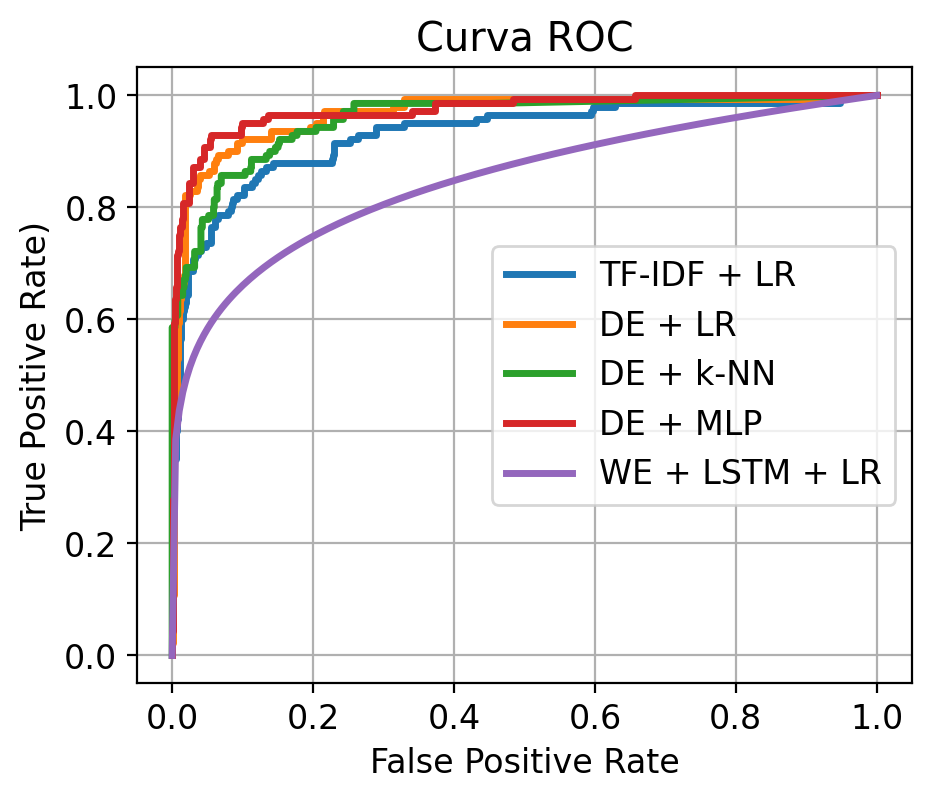

El área bajo la curva ROC de TF-IDF + LR es 0.9300796812749004
El área bajo la curva ROC de Doc-Embeddings + LR es 0.9650327262379055
El área bajo la curva ROC de Doc-Embeddings + kNN es 0.9575626067159931
El área bajo la curva ROC de Doc-Embeddings + MLP es 0.9730008537279454
El área bajo la curva ROC de Word-Embeddings + LSTM + LR es 0.846756165740385


In [6]:
fig = plt.figure(figsize=(5, 4))

fpr_TFIDF_LR = Performance_TFIDF_LR_dict["fpr_TFIDF_LR"]
tpr_TFIDF_LR = Performance_TFIDF_LR_dict["tpr_TFIDF_LR"]
area_roc_TFIDF_LR = Performance_TFIDF_LR_dict["area_roc_TFIDF_LR"]

fpr_DE_LR = Performance_DE_LR_dict["fpr_DE_LR"]
tpr_DE_LR = Performance_DE_LR_dict["tpr_DE_LR"]
area_roc_DE_LR = Performance_DE_LR_dict["area_roc_DE_LR"]

fpr_DE_kNN = Performance_DE_kNN_dict["fpr_DE_kNN"]
tpr_DE_kNN = Performance_DE_kNN_dict["tpr_DE_kNN"]
area_roc_DE_kNN = Performance_DE_kNN_dict["area_roc_DE_kNN"]

fpr_DE_MLP = Performance_DE_MLP_dict["fpr_DE_MLP"]
tpr_DE_MLP = Performance_DE_MLP_dict["tpr_DE_MLP"]
area_roc_DE_MLP = Performance_DE_MLP_dict["area_roc_DE_MLP"]

fpr_WE_LSTM_LR = Performance_WE_LSTM_LR_dict["fpr_WE_LSTM_LR"]
tpr_WE_LSTM_LR = Performance_WE_LSTM_LR_dict["tpr_WE_LSTM_LR"]
area_roc_WE_LSTM_LR = Performance_WE_LSTM_LR_dict["area_roc_WE_LSTM_LR"]

plt.plot(fpr_TFIDF_LR, tpr_TFIDF_LR, lw=2.5,label='TF-IDF + LR ')
plt.plot(fpr_DE_LR, tpr_DE_LR, lw=2.5, label='DE + LR')
plt.plot(fpr_DE_kNN, tpr_DE_kNN, lw=2.5, label='DE + k-NN')
plt.plot(fpr_DE_MLP, tpr_DE_MLP, lw=2.5, label='DE + MLP')
plt.plot(fpr_WE_LSTM_LR, tpr_WE_LSTM_LR, lw=2.5, label='WE + LSTM + LR')
plt.legend(loc=7)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate)')
plt.title('Curva ROC')
plt.show()

print(f"El área bajo la curva ROC de TF-IDF + LR es {area_roc_TFIDF_LR}")
print(f"El área bajo la curva ROC de Doc-Embeddings + LR es {area_roc_DE_LR}")
print(f"El área bajo la curva ROC de Doc-Embeddings + kNN es {area_roc_DE_kNN}")
print(f"El área bajo la curva ROC de Doc-Embeddings + MLP es {area_roc_DE_MLP}")
print(f"El área bajo la curva ROC de Word-Embeddings + LSTM + LR es {area_roc_WE_LSTM_LR}")

El uso de los modelos preentrenados es bastante directo. Comencemos por utilizar BERT, el modelo por defecto en la librería para la tarea "sentiment analysis".

Vamos a evaluar directamente las prestaciones de estos modelos preentrenados en el conjunto de test, para comparar con los modelos anteriores. No será necesario utilizar entrenamiento ni validación, pues **no vamos a hacer "fine-tuning"**.

**NOTA IMPORTANTE**: el modelo recibe una lista de tokens, y la longitud de dicha lista está limitada a 512. En nuestro dataset ese límite no supone un problema pero en otros datasets puede ser necesario recortar la entrada.

In [7]:
frases = finantial_dataset["frases"]
idx_test = finantial_dataset["idx_test"]
frases_test = [frases[i] for i in idx_test]
y_test = finantial_dataset["y_test"]

print("\nLa entrada al modelo BERT son los textos sin preprocesar, esta sería el primer texto:\n")
print(frases_test[0])


La entrada al modelo BERT son los textos sin preprocesar, esta sería el primer texto:

Sullivan said some of the boards `` really involve a lot of work , and people should get paid for their time . ''


In [ ]:
# Calculamos las predicciones con BERT. El modelo usado por defecto es "distilbert-base-uncased-finetuned-sst-2-english"
from transformers import pipeline

sentiment_pipeline = pipeline(task="sentiment-analysis")
out_bert = sentiment_pipeline(frases_test)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8406.88it/s]


Vemos que **por defecto, la tarea de "sentiment-analysis" utiliza el modelo [DistilBERT base uncased finetuned SST-2](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english)**.

Este modelo es un **ajuste fino** del modelo **``DistilBERT-base-uncased`` sobre SST-2 (Stanford Sentiment Treebank)**, presentado en el artículo [Recursive Deep Models for Semantic Compositionality Over a Sentiment Treebank](https://aclanthology.org/D13-1170.pdf).


El formato de salida de cada uno de estos modelos puede ser ligeramente diferente, conviene explorar el resultado antes de continuar y adaptarlo a nuestras necesidades.

In [ ]:
for k in range(5):
  print(out_bert[k])

print("\nEl modelo asigna a cada texto una de las siguientes categorías:")
classes = [p['label'] for p in out_bert]
print(set(classes))

{'label': 'POSITIVE', 'score': 0.9674737453460693}
{'label': 'NEGATIVE', 'score': 0.9872972965240479}
{'label': 'NEGATIVE', 'score': 0.9913676381111145}
{'label': 'POSITIVE', 'score': 0.9341431260108948}
{'label': 'POSITIVE', 'score': 0.9957821369171143}

El modelo asigna a cada texto una de las siguientes categorías:
{'NEGATIVE', 'POSITIVE'}


Vemos por tanto que para cada texto se produce una salida que es un diccionario. El campo 'label' contiene tanto la decisión final del modelo (POSITIVE/NEGATIVE) como una medida de la certeza del modelo acerca de dicha decision "score".

Transformamos estas salidas en las decisiones blandas que necesitamos para comparar nuestros modelos (cálculo de ROC y AUC):

In [ ]:
preds_proba_bert = [1-out_bert[i]['score'] if out_bert[i]['label']=="POSITIVE" else out_bert[i]['score'] for i in range(len(out_bert))]
print(preds_proba_bert[0:5])
print(y_test[0:5])

[0.032526254653930664, 0.9872972965240479, 0.9913676381111145, 0.06585687398910522, 0.004217863082885742]
[0 1 0 0 0]


Las decisiones "duras" se pueden obtener de dos formas. O bien utilizamos directamente las etiquetas proporcionadas por el modelo (campo 'label'), o bien aplicamos un umbral de 0.5 a las decisiones blandas. En ambos casos obtenemos los mismos resultados.

In [ ]:
decis_bert1 = [0 if out_bert[i]['label']=="POSITIVE" else 1 for i in range(len(out_bert))]
accuracy_test_BERT = np.sum(decis_bert1 == y_test) / len(y_test)
print("Accuracy 1 test {}%\n".format( accuracy_test_BERT*100))

decis_bert2 = [1 if preds_proba_bert[i] > 0.5 else 0 for i in range(len(preds_proba_bert))]
accuracy_test_BERT = np.sum(decis_bert2 == y_test) / len(y_test)
print("Accuracy 2 test {}%\n".format( accuracy_test_BERT*100))


Accuracy 1 test 53.75874125874126%

Accuracy 2 test 53.75874125874126%



Comparemos los resultados obtenidos con los demás modelos:

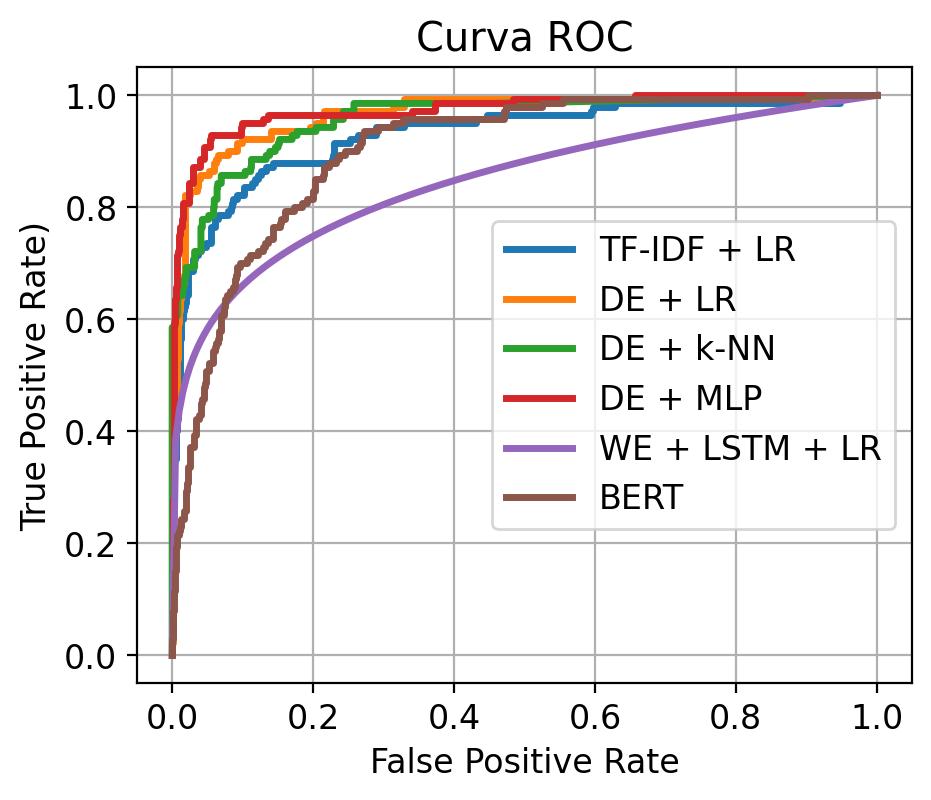

El área bajo la curva ROC de TF-IDF + LR es 0.9300796812749004
El área bajo la curva ROC de Doc-Embeddings + LR es 0.9650327262379055
El área bajo la curva ROC de Doc-Embeddings + kNN es 0.9575626067159931
El área bajo la curva ROC de Doc-Embeddings + MLP es 0.9730008537279454
El área bajo la curva ROC de Word-Embeddings + LSTM + LR es 0.846756165740385
El área bajo la curva ROC de BERT es 0.9010031303357996


In [ ]:
fpr_BERT, tpr_BERT, thresholds_fprtpr_BERT = metrics.roc_curve(y_test, preds_proba_bert, pos_label=1)

fig = plt.figure(figsize=(5, 4))
plt.plot(fpr_TFIDF_LR, tpr_TFIDF_LR, lw=2.5,label='TF-IDF + LR ')
plt.plot(fpr_DE_LR, tpr_DE_LR, lw=2.5, label='DE + LR')
plt.plot(fpr_DE_kNN, tpr_DE_kNN, lw=2.5, label='DE + k-NN')
plt.plot(fpr_DE_MLP, tpr_DE_MLP, lw=2.5, label='DE + MLP')
plt.plot(fpr_WE_LSTM_LR, tpr_WE_LSTM_LR, lw=2.5, label='WE + LSTM + LR')
plt.plot(fpr_BERT, tpr_BERT, lw=2.5, label='BERT')
plt.legend(loc=7)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate)')
plt.title('Curva ROC')
plt.show()

area_roc_BERT = metrics.roc_auc_score(y_test, preds_proba_bert)

print(f"El área bajo la curva ROC de TF-IDF + LR es {area_roc_TFIDF_LR}")
print(f"El área bajo la curva ROC de Doc-Embeddings + LR es {area_roc_DE_LR}")
print(f"El área bajo la curva ROC de Doc-Embeddings + kNN es {area_roc_DE_kNN}")
print(f"El área bajo la curva ROC de Doc-Embeddings + MLP es {area_roc_DE_MLP}")
print(f"El área bajo la curva ROC de Word-Embeddings + LSTM + LR es {area_roc_WE_LSTM_LR}")
print(f"El área bajo la curva ROC de BERT es {area_roc_BERT}")

#El área bajo la curva ROC de TF-IDF + LR es 0.9373221400113831
#El área bajo la curva ROC de Doc-Embeddings + LR es 0.9498648264086511
#El área bajo la curva ROC de Doc-Embeddings + kNN es 0.9788133181559476
#El área bajo la curva ROC de Doc-Embeddings + MLP es 0.9603229937393284
#El área bajo la curva ROC de Word-Embeddings + LSTM + LR es 0.9355435401252132
# El área bajo la curva ROC de BERT es 0.9010031303357996

Vemos que hay una gran discrepancia entre el valor de accuracy obtenido (53.75%) y el valor de AUC (0.9). Veremos a continuación que el uso de umbral 0.5 no es la mejor de las elecciones.

Representemos los valores de FPR, TPR y Accuracy en función del umbral:

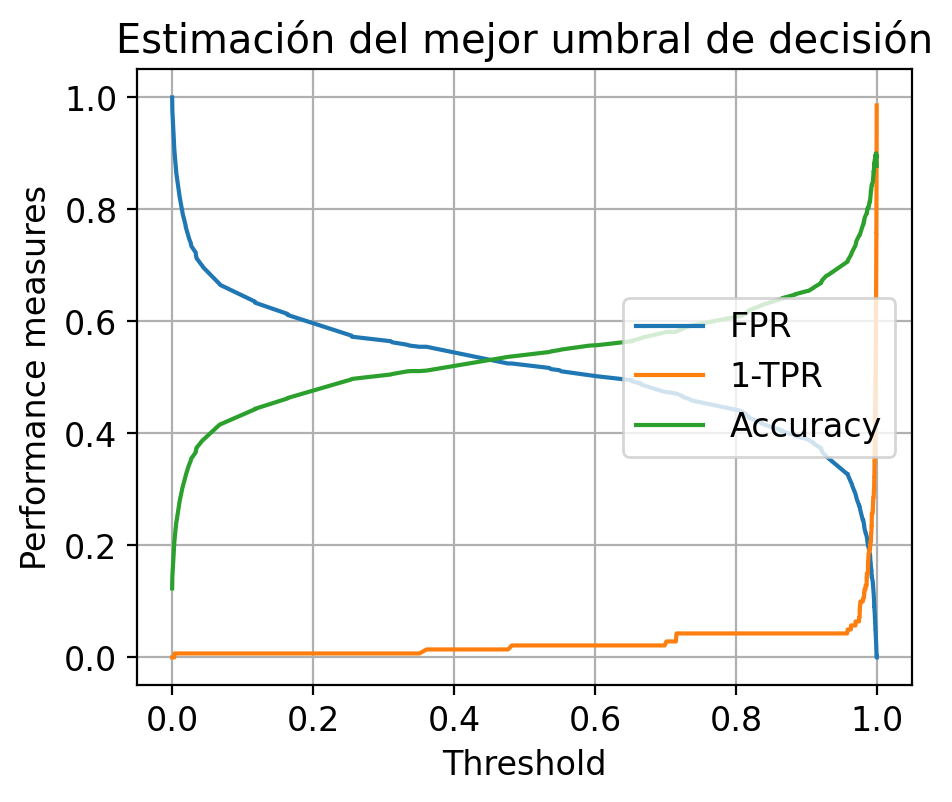

In [ ]:
Nth = len(thresholds_fprtpr_BERT)
Npreds = len(preds_proba_bert)
Accuracies = np.zeros(Nth)
for i in range(Nth):
  decis = [1 if preds_proba_bert[j] > thresholds_fprtpr_BERT[i] else 0 for j in range(Npreds)]
  Accuracies[i] = np.sum(decis == y_test) / len(y_test)

fig = plt.figure(figsize=(5, 4))
plt.plot(thresholds_fprtpr_BERT, fpr_BERT, label='FPR')
plt.plot(thresholds_fprtpr_BERT, 1-tpr_BERT, label='1-TPR')
plt.plot(thresholds_fprtpr_BERT, Accuracies, label='Accuracy')
plt.legend(loc=7)
plt.grid()
plt.xlabel('Threshold')
plt.ylabel('Performance measures')
plt.title('Estimación del mejor umbral de decisión')
plt.show()



Hacemos "zoom" para ver mejor el punto de cruce:

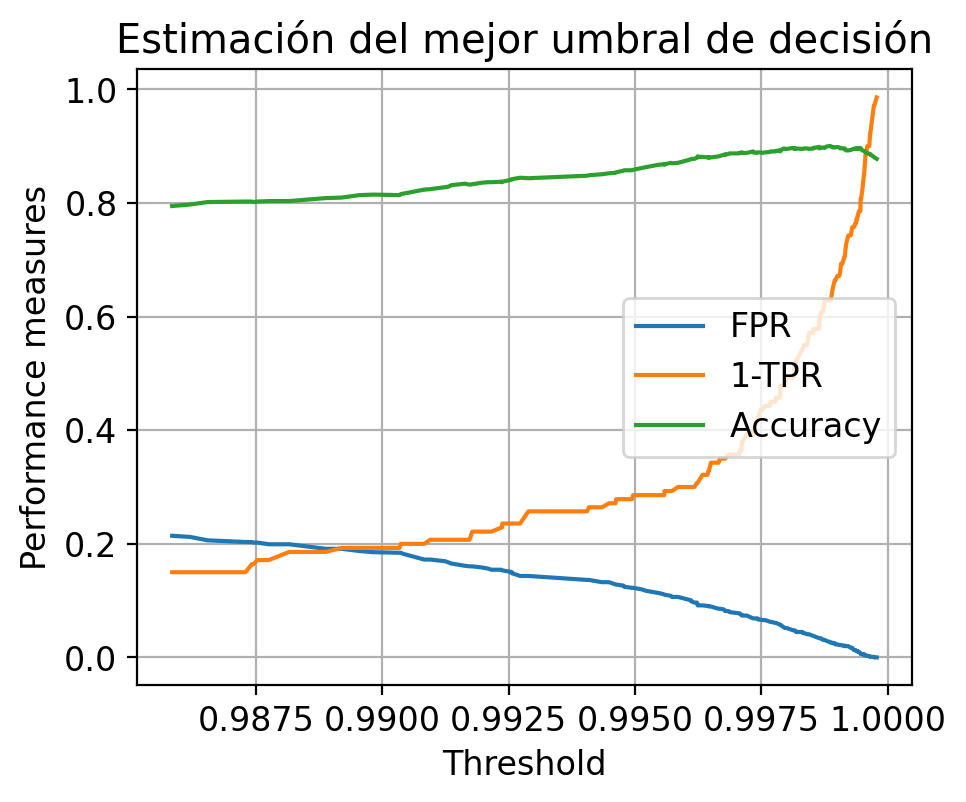

In [ ]:
fig = plt.figure(figsize=(5, 4))
plt.plot(thresholds_fprtpr_BERT[1:160], fpr_BERT[1:160], label='FPR')
plt.plot(thresholds_fprtpr_BERT[1:160], 1-tpr_BERT[1:160], label='1-TPR')
plt.plot(thresholds_fprtpr_BERT[1:160], Accuracies[1:160], label='Accuracy')
plt.legend(loc=7)
plt.grid()
plt.xlabel('Threshold')
plt.ylabel('Performance measures')
plt.title('Estimación del mejor umbral de decisión')
plt.show()

Probamos con umbral 0.99:

In [ ]:
decis_bert = [1 if preds_proba_bert[i] > 0.99 else 0 for i in range(len(preds_proba_bert))]
accuracy_test_BERT = np.sum(decis_bert == y_test) / len(y_test)
print("Accuracy test {}%\n".format( accuracy_test_BERT*100))

Accuracy test 81.46853146853147%



Vemos por tanto la importancia de elegir bien el umbral de decisión, hemos pasado de una accuracy del 57.3% al 81.4%. En todo caso, las prestaciones de este modelo Transformer está por debajo del accuracy del modelo "baseline" (El % de acierto en test de un clasificador base que decide siempre '0' es = 87.7%.). Con umbral = 1 alcanzamos dichas prestaciones, pero el modelo no está discriminando nada.

## Ejercicio:

calcular las prestaciones con otro de los modelos disponibles (**Roberta**). Para ello usaremos el modelo ``cardiffnlp/twitter-roberta-base-sentiment-latest``. Calcule la Accuracy, el AUC y compare la curva ROC con el resto de modelos.


In [ ]:
# RoBERTa: cardiffnlp/twitter-roberta-base-sentiment-latest
# El modelo etiqueta cada texto como 'positive', 'neutral' o 'negative'.
sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    top_k=None,   # devuelve todas las clases con sus scores
)
out_roberta = sentiment_pipeline(frases_test)

def _roberta_neg_proba(scores):
    """Convierte la lista de {label, score} de Roberta en P(negativo)."""
    d = {item['label'].lower(): item['score'] for item in scores}
    # Algunas variantes devuelven 'LABEL_0/1/2' -> mapear si fuera el caso.
    if 'negative' in d:
        return d['negative']
    label_map = {'label_0': 'negative', 'label_1': 'neutral', 'label_2': 'positive'}
    d = {label_map.get(k, k): v for k, v in d.items()}
    return d.get('negative', 0.0)

preds_proba_roberta = [_roberta_neg_proba(s) for s in out_roberta]
decis_roberta = [1 if p > 0.5 else 0 for p in preds_proba_roberta]
accuracy_test_roberta = np.sum(decis_roberta == y_test) / len(y_test)
print("Accuracy test Roberta {}%\n".format( accuracy_test_roberta*100))
fpr_roberta, tpr_roberta, thresholds_fprtpr_roberta = metrics.roc_curve(y_test, preds_proba_roberta, pos_label=1)
area_roc_Roberta = metrics.roc_auc_score(y_test, preds_proba_roberta)
print(f"El área bajo la curva ROC de Roberta es {area_roc_Roberta}")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 26464.56it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Accuracy test Roberta 92.13286713286713%

El área bajo la curva ROC de Roberta es 0.9531303357996586


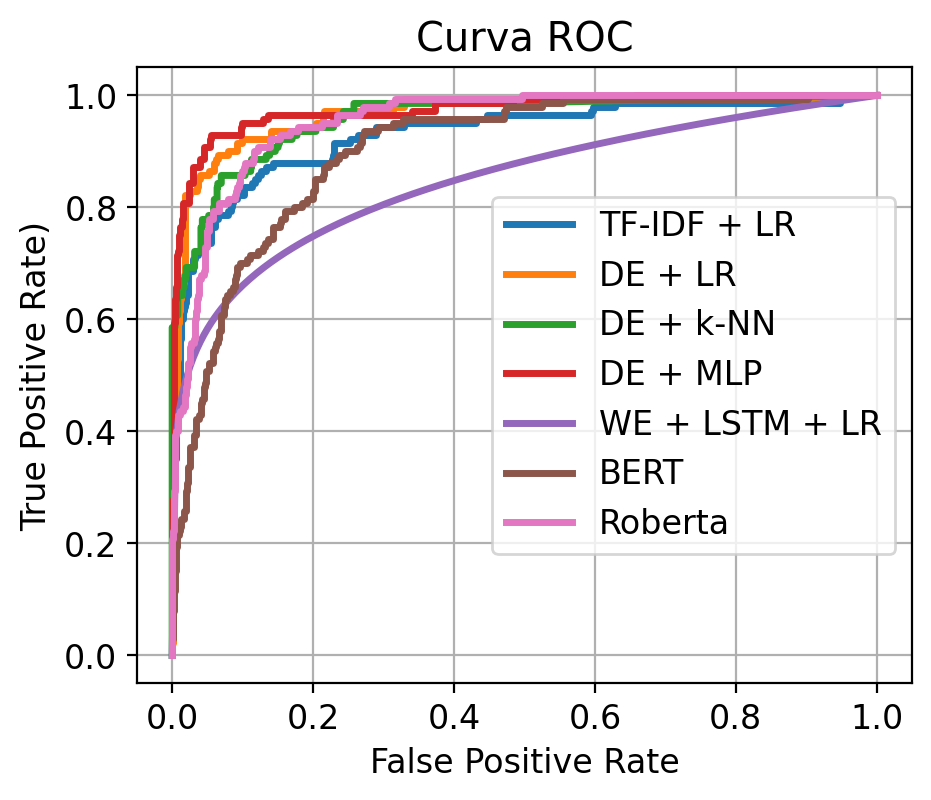

El área bajo la curva ROC de TF-IDF + LR es 0.9300796812749004
El área bajo la curva ROC de Doc-Embeddings + LR es 0.9650327262379055
El área bajo la curva ROC de Doc-Embeddings + kNN es 0.9575626067159931
El área bajo la curva ROC de Doc-Embeddings + MLP es 0.9730008537279454
El área bajo la curva ROC de Word-Embeddings + LSTM + LR es 0.846756165740385
El área bajo la curva ROC de BERT es 0.9010031303357996
El área bajo la curva ROC de Roberta es 0.9531303357996586


In [ ]:
fig = plt.figure(figsize=(5, 4))
plt.plot(fpr_TFIDF_LR, tpr_TFIDF_LR, lw=2.5,label='TF-IDF + LR ')
plt.plot(fpr_DE_LR, tpr_DE_LR, lw=2.5, label='DE + LR')
plt.plot(fpr_DE_kNN, tpr_DE_kNN, lw=2.5, label='DE + k-NN')
plt.plot(fpr_DE_MLP, tpr_DE_MLP, lw=2.5, label='DE + MLP')
plt.plot(fpr_WE_LSTM_LR, tpr_WE_LSTM_LR, lw=2.5, label='WE + LSTM + LR')
plt.plot(fpr_BERT, tpr_BERT, lw=2.5, label='BERT')
plt.plot(fpr_roberta, tpr_roberta, lw=2.5, label='Roberta')
plt.legend(loc=7)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate)')
plt.title('Curva ROC')
plt.show()

print(f"El área bajo la curva ROC de TF-IDF + LR es {area_roc_TFIDF_LR}")
print(f"El área bajo la curva ROC de Doc-Embeddings + LR es {area_roc_DE_LR}")
print(f"El área bajo la curva ROC de Doc-Embeddings + kNN es {area_roc_DE_kNN}")
print(f"El área bajo la curva ROC de Doc-Embeddings + MLP es {area_roc_DE_MLP}")
print(f"El área bajo la curva ROC de Word-Embeddings + LSTM + LR es {area_roc_WE_LSTM_LR}")
print(f"El área bajo la curva ROC de BERT es {area_roc_BERT}")
print(f"El área bajo la curva ROC de Roberta es {area_roc_Roberta}")

#El área bajo la curva ROC de TF-IDF + LR es 0.9373221400113831
#El área bajo la curva ROC de Doc-Embeddings + LR es 0.9498648264086511
#El área bajo la curva ROC de Doc-Embeddings + kNN es 0.9788133181559476
#El área bajo la curva ROC de Doc-Embeddings + MLP es 0.9603229937393284
#El área bajo la curva ROC de Word-Embeddings + LSTM + LR es 0.9355435401252132
# El área bajo la curva ROC de BERT es 0.9010031303357996
# El área bajo la curva ROC de Roberta es 0.8482142857142858

## Ejercicio:

Probemos finalmente con **FinBert** (``ProsusAI/finbert``), un modelo específicamente  preentrenado para analizar el sentimiento de textos financieros como los de nuestro dataset. Repita los mismos pasos que para los modelos anteriores.

In [ ]:
# FinBERT: ProsusAI/finbert (etiquetas: positive / negative / neutral)
sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model="ProsusAI/finbert",
    top_k=None,
)
out_finbert = sentiment_pipeline(frases_test)

def _finbert_neg_proba(scores):
    """Convierte la salida de FinBERT en P(negativo)."""
    d = {item['label'].lower(): item['score'] for item in scores}
    return d.get('negative', 0.0)

preds_proba_finbert = [_finbert_neg_proba(s) for s in out_finbert]
preds_finbert = preds_proba_finbert  # alias usado más abajo
decis_finbert = [1 if p > 0.5 else 0 for p in preds_proba_finbert]
accuracy_test_finbert = np.sum(decis_finbert == y_test) / len(y_test)
print("Accuracy test FinBERT {}%\n".format( accuracy_test_finbert*100))
fpr_finbert, tpr_finbert, thresholds_fprtpr_finbert = metrics.roc_curve(y_test, preds_finbert, pos_label=1)
area_roc_FinBERT = metrics.roc_auc_score(y_test, preds_proba_finbert)
print(f"El área bajo la curva ROC de FinBERT es {area_roc_FinBERT}")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 24184.72it/s]


Accuracy test FinBERT 98.51398601398601%

El área bajo la curva ROC de FinBERT es 0.9972182697780307


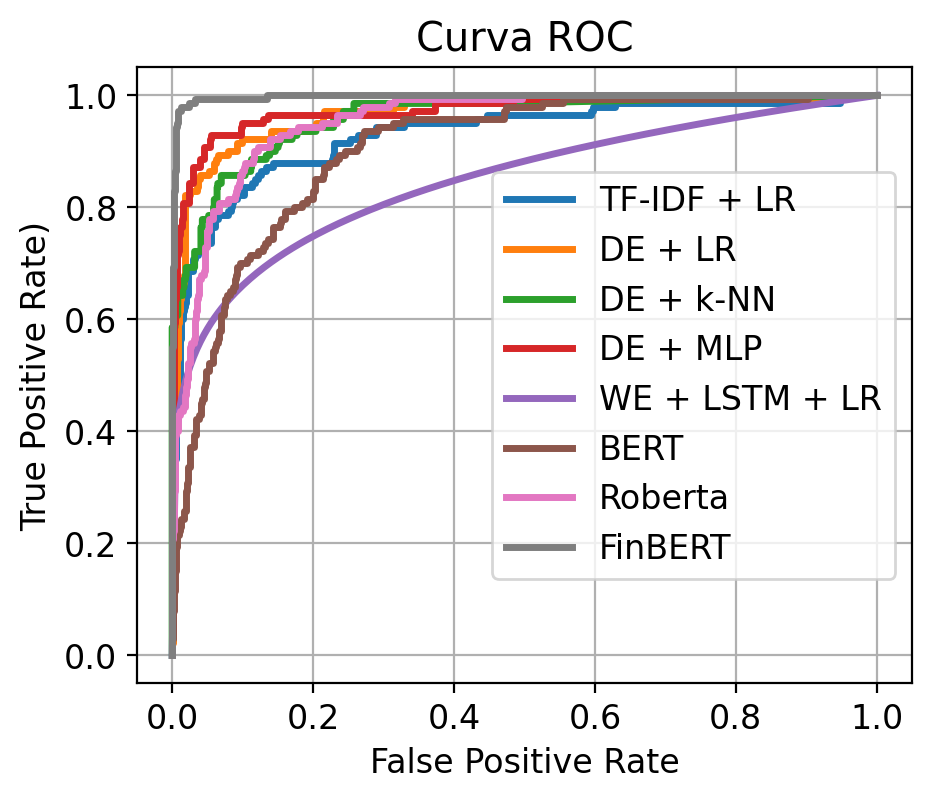

El área bajo la curva ROC de TF-IDF + LR es 0.9300796812749004
El área bajo la curva ROC de Doc-Embeddings + LR es 0.9650327262379055
El área bajo la curva ROC de Doc-Embeddings + kNN es 0.9575626067159931
El área bajo la curva ROC de Doc-Embeddings + MLP es 0.9730008537279454
El área bajo la curva ROC de Word-Embeddings + LSTM + LR es 0.846756165740385
El área bajo la curva ROC de BERT es 0.9010031303357996
El área bajo la curva ROC de Roberta es 0.9531303357996586
El área bajo la curva ROC de FinBERT es 0.9972182697780307


In [ ]:
fig = plt.figure(figsize=(5, 4))
plt.plot(fpr_TFIDF_LR, tpr_TFIDF_LR, lw=2.5,label='TF-IDF + LR ')
plt.plot(fpr_DE_LR, tpr_DE_LR, lw=2.5, label='DE + LR')
plt.plot(fpr_DE_kNN, tpr_DE_kNN, lw=2.5, label='DE + k-NN')
plt.plot(fpr_DE_MLP, tpr_DE_MLP, lw=2.5, label='DE + MLP')
plt.plot(fpr_WE_LSTM_LR, tpr_WE_LSTM_LR, lw=2.5, label='WE + LSTM + LR')
plt.plot(fpr_BERT, tpr_BERT, lw=2.5, label='BERT')
plt.plot(fpr_roberta, tpr_roberta, lw=2.5, label='Roberta')
plt.plot(fpr_finbert, tpr_finbert, lw=2.5, label='FinBERT')
plt.legend(loc=7)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate)')
plt.title('Curva ROC')
plt.show()

print(f"El área bajo la curva ROC de TF-IDF + LR es {area_roc_TFIDF_LR}")
print(f"El área bajo la curva ROC de Doc-Embeddings + LR es {area_roc_DE_LR}")
print(f"El área bajo la curva ROC de Doc-Embeddings + kNN es {area_roc_DE_kNN}")
print(f"El área bajo la curva ROC de Doc-Embeddings + MLP es {area_roc_DE_MLP}")
print(f"El área bajo la curva ROC de Word-Embeddings + LSTM + LR es {area_roc_WE_LSTM_LR}")
print(f"El área bajo la curva ROC de BERT es {area_roc_BERT}")
print(f"El área bajo la curva ROC de Roberta es {area_roc_Roberta}")
print(f"El área bajo la curva ROC de FinBERT es {area_roc_FinBERT}")

#El área bajo la curva ROC de TF-IDF + LR es 0.9373221400113831
#El área bajo la curva ROC de Doc-Embeddings + LR es 0.9498648264086511
#El área bajo la curva ROC de Doc-Embeddings + kNN es 0.9788133181559476
#El área bajo la curva ROC de Doc-Embeddings + MLP es 0.9603229937393284
#El área bajo la curva ROC de Word-Embeddings + LSTM + LR es 0.9355435401252132
# El área bajo la curva ROC de BERT es 0.9010031303357996
# El área bajo la curva ROC de Roberta es 0.8482142857142858
# El área bajo la curva ROC de FinBERT es 0.9941733067729083

Como vemos, los resultados de FinBERT son impresionantes, porque ha sido ajustado de forma fina precisamente con estos datos!

Sin embargo, modelos pre-entrenados para otros propósitos u otras BBDD pueden funcionar incluso peor que los baselines.

## Ejercicio de ampliación:

Para cada uno de los modelos entrenados, obtenga el mejor umbral de decisión y compare los resultados de Accuracy con umbral 0.5 y con el nuevo umbral.  

# 13.- Traducción automática

**NOTA de HUGGINGFACE** (2026): ``The translation pipeline has been removed in v5! This is because the quality of translations from Seq2Seq models was generally worse than using LLMs instead, and we didn't want pipelines to mislead users. We probably need to remove all the leftover translation references in the pipeline files entirely.``

A efectos demostrativos, vamos a utilizar las librerías de transformers antiguas para traducir los textos a varios idiomas. Veamos un ejemplos de uso. En primer lugar cargamos el pipeline ``translation_en_to_fr`` y probamos su funcionamiento:

In [ ]:
# La tarea "translation_en_to_xx" fue eliminada en transformers 5.x.
# Forzamos la instalación de transformers 4.51.3 e invalidamos el módulo en memoria.
import sys, subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "transformers==4.51.3", "tokenizers<0.20", "huggingface_hub<0.27"])

# Eliminamos transformers (y submódulos) del cache para que el siguiente import recargue 4.51.3
for mod in list(sys.modules):
    if mod == "transformers" or mod.startswith("transformers."):
        del sys.modules[mod]

import importlib, transformers
importlib.reload(transformers)
print(f"Transformers re-importado: {transformers.__version__}")
print("Si la versión sigue mostrando 5.x, REINICIA el kernel y vuelve a ejecutar desde aquí.")


In [ ]:
# Comprobamos que la tarea de traducción está disponible
import transformers
print(f"Transformers version: {transformers.__version__}")
assert transformers.__version__.startswith("4."), \
    "La versión de transformers sigue siendo 5.x. Reinicia el kernel y vuelve a ejecutar la celda anterior."

transformers.logging.set_verbosity_error()

from transformers import pipeline
from transformers.pipelines import SUPPORTED_TASKS

for task in SUPPORTED_TASKS.keys():
    print(task)


In [ ]:
# Forma robusta: usar la tarea genérica "translation" y dejar que el modelo
# Helsinki-NLP/opus-mt-en-fr resuelva el par de idiomas.
en_fr_translator = pipeline(
    task="translation",
    model="Helsinki-NLP/opus-mt-en-fr",
    tokenizer="Helsinki-NLP/opus-mt-en-fr",
)


In [ ]:
frase_frances = en_fr_translator("How old are you?")
print("Traducción al francés: {}".format(frase_frances[0]['translation_text']))

## Ejercicio:

Instancie los transformers de traducción al alemán y español (``Helsinki-NLP/opus-mt-tc-big-en-es``) y pruebe a traducir la frase anterior.

**Nota:** algunos transformers de traducción pueden estar disponibles en diferentes formatos, se aconseja revisar la [documentación de la librería](https://huggingface.co/docs/transformers/tasks/translation).  

In [ ]:
# Traductores Inglés -> Alemán e Inglés -> Español
en_de_translator = pipeline(task="translation", model="Helsinki-NLP/opus-mt-en-de")
en_es_translator = pipeline(task="translation", model="Helsinki-NLP/opus-mt-tc-big-en-es")

frase_aleman   = en_de_translator("How old are you?")
frase_espanol  = en_es_translator("How old are you?")

print("Traducción al alemán : {}".format(frase_aleman[0]['translation_text']))
print("Traducción al español: {}".format(frase_espanol[0]['translation_text']))


## Ejercicio:

Localice en la librería el mayor número posible de transformers de traducción de inglés a otros idiomas y pruebe a traducir una de las frases del dataset elegida aleatoriamente.

In [ ]:
# Una colección de traductores Inglés -> X usando los modelos Helsinki-NLP/Opus-MT.
# Cada entrada es (código_idioma, identificador_modelo_HF).
import random

translators_info = [
    ("fr",  "Helsinki-NLP/opus-mt-en-fr"),       # Francés
    ("de",  "Helsinki-NLP/opus-mt-en-de"),       # Alemán
    ("es",  "Helsinki-NLP/opus-mt-tc-big-en-es"),# Español
    ("it",  "Helsinki-NLP/opus-mt-en-it"),       # Italiano
    ("nl",  "Helsinki-NLP/opus-mt-en-nl"),       # Neerlandés
    ("ar",  "Helsinki-NLP/opus-mt-en-ar"),       # Árabe
    ("zh",  "Helsinki-NLP/opus-mt-en-zh"),       # Chino
    ("ja",  "Helsinki-NLP/opus-mt-en-jap"),      # Japonés
    ("ro",  "Helsinki-NLP/opus-mt-en-ro"),       # Rumano
    ("sv",  "Helsinki-NLP/opus-mt-en-sv"),       # Sueco
    ("fi",  "Helsinki-NLP/opus-mt-en-fi"),       # Finés
]

# Elegimos una frase aleatoria del dataset financiero.
random.seed(0)
idx_random = random.randint(0, len(frases) - 1)
frase = frases[idx_random]
print(f"Frase seleccionada (idx={idx_random}):\n{frase}\n")

translations = {}
for lang, model_name in translators_info:
    try:
        tr = pipeline("translation", model=model_name)
        out = tr(frase)
        translations[lang] = out[0]['translation_text']
        print(f"[{lang}] ({model_name}) -> {translations[lang]}")
    except Exception as e:
        print(f"[{lang}] ({model_name}) ERROR: {type(e).__name__}: {e}")


## Ejercicio de ampliación:

Añada también los traductores al húngaro (`NYTK/translation-mt5-small-128-en-hu`) y al ruso (`glazzova/translation_en_ru`).

In [ ]:
# Traductores adicionales: húngaro y ruso.
en_hu_translator = pipeline("translation", model="NYTK/translation-mt5-small-128-en-hu")
en_ru_translator = pipeline("translation", model="glazzova/translation_en_ru")

frase_hu = en_hu_translator(frase)
frase_ru = en_ru_translator(frase)

print("Frase original (en): {}\n".format(frase))
print("Traducción al húngaro: {}".format(frase_hu[0]['translation_text']))
print("Traducción al ruso   : {}".format(frase_ru[0]['translation_text']))


# Los modelos M2M100 de Meta (418M y 1.2B)

M2M100 (M2M100 significa "Many-to-Many, 100 languages") es un modelo de lenguaje de inteligencia artificial desarrollado por Meta específicamente para la traducción automática multilingüe. Este modelo puede traducir entre **100 idiomas diferentes directamente**, sin pasar por el inglés como idioma puente.

Utiliza la arquitectura basada en Transformers con un codificador y un decodificador, de modo que se puede utilizar directamente desde la librería Python "Transformers", con el pipeline de traducción general visto hasta ahora.

Disponibles en tres tamaños:

- **418M** (``facebook/m2m100_418M``): 418 Millones de parámetros, modelo de tamaño mediano y relativamente rápido y eficiente en comparación con versiones más grandes

- **1.2B** (``facebook/m2m100_1.2B``): 1.2 "billions" de parámetros, ofrece equilibrio entre calidad de traducción y velocidad.

- **12B** (``facebook/m2m100-12B``): esta versión masiva de 12 "billions" de parámetros generalmente no se utiliza con pipeline de Hugging Face directamente debido a sus altísimos requerimientos de VRAM (se necesitan múltiples GPUs de gama alta).

Los idiomas disponibles se listan en la página web del modelo:

https://huggingface.co/facebook/m2m100_418M

Languages covered
Afrikaans (af), Amharic (am), Arabic (ar), Asturian (ast), Azerbaijani (az), Bashkir (ba), Belarusian (be), Bulgarian (bg), Bengali (bn), Breton (br), Bosnian (bs), Catalan; Valencian (ca), Cebuano (ceb), Czech (cs), Welsh (cy), Danish (da), German (de), Greeek (el), English (en), Spanish (es), Estonian (et), Persian (fa), Fulah (ff), Finnish (fi), French (fr), Western Frisian (fy), Irish (ga), Gaelic; Scottish Gaelic (gd), Galician (gl), Gujarati (gu), Hausa (ha), Hebrew (he), Hindi (hi), Croatian (hr), Haitian; Haitian Creole (ht), Hungarian (hu), Armenian (hy), Indonesian (id), Igbo (ig), Iloko (ilo), Icelandic (is), Italian (it), Japanese (ja), Javanese (jv), Georgian (ka), Kazakh (kk), Central Khmer (km), Kannada (kn), Korean (ko), Luxembourgish; Letzeburgesch (lb), Ganda (lg), Lingala (ln), Lao (lo), Lithuanian (lt), Latvian (lv), Malagasy (mg), Macedonian (mk), Malayalam (ml), Mongolian (mn), Marathi (mr), Malay (ms), Burmese (my), Nepali (ne), Dutch; Flemish (nl), Norwegian (no), Northern Sotho (ns), Occitan (post 1500) (oc), Oriya (or), Panjabi; Punjabi (pa), Polish (pl), Pushto; Pashto (ps), Portuguese (pt), Romanian; Moldavian; Moldovan (ro), Russian (ru), Sindhi (sd), Sinhala; Sinhalese (si), Slovak (sk), Slovenian (sl), Somali (so), Albanian (sq), Serbian (sr), Swati (ss), Sundanese (su), Swedish (sv), Swahili (sw), Tamil (ta), Thai (th), Tagalog (tl), Tswana (tn), Turkish (tr), Ukrainian (uk), Urdu (ur), Uzbek (uz), Vietnamese (vi), Wolof (wo), Xhosa (xh), Yiddish (yi), Yoruba (yo), Chinese (zh), Zulu (zu)

Veamos un ejemplo de uso:

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

t_m2m100_418M = AutoTokenizer.from_pretrained("facebook/m2m100_418M")

m_m2m100_418M = AutoModelForSeq2SeqLM.from_pretrained("facebook/m2m100_418M")

In [ ]:
m2m100_en_de = pipeline('translation', model=m_m2m100_418M, tokenizer=t_m2m100_418M, src_lang='en', tgt_lang="de")
m2m100_en_fr = pipeline('translation', model=m_m2m100_418M, tokenizer=t_m2m100_418M, src_lang='en', tgt_lang="fr")
print(m2m100_en_de(frase))
print(m2m100_en_fr(frase))

In [ ]:
m2m100_en_pt = pipeline('translation', model=m_m2m100_418M, tokenizer=t_m2m100_418M, src_lang='en', tgt_lang="pt")
print(m2m100_en_pt(frase))


In [ ]:
m2m100_en_hi = pipeline('translation', model=m_m2m100_418M, tokenizer=t_m2m100_418M, src_lang='en', tgt_lang="hi")
print(m2m100_en_hi(frase))

In [ ]:
m2m100_en_ko = pipeline('translation', model=m_m2m100_418M, tokenizer=t_m2m100_418M, src_lang='en', tgt_lang="ko")
print(m2m100_en_ko(frase))

# Tarea de ampliación:

- Obtener como lista python, los identificadores de todos los idiomas soportados en `facebook/m2m100_418M`.

- Crear a partir de dicha lista un diccionario `dicc_lan` conteniendo el nombre completo del idioma, es decir, `dicc_lan["af"]` debe contener "Afrikaans".

- Mostrar el listado completo de códigos y nombres completos, de la forma:

af -> Afrikaans

am -> Amharic

ar -> Arabic

ast -> Asturian

**Nota**: La lista completa de idiomas está disponible en `tokenizer.lang_code_to_id` y puede ayudarse de la librería `pycountry` para hacer la conversión entre códigos y nombres de países.

In [ ]:
# Listamos todos los idiomas soportados por facebook/m2m100_418M y construimos
# un diccionario con su nombre completo.
import pycountry

# Códigos de idioma soportados por el tokenizer.
codigos_idiomas = sorted(t_m2m100_418M.lang_code_to_id.keys())
print(f"Total de idiomas soportados: {len(codigos_idiomas)}\n")

# Algunos códigos no son ISO-639-1 estándar; añadimos un mapa manual.
manual_map = {
    "ast": "Asturian",
    "ceb": "Cebuano",
    "ff":  "Fulah",
    "ilo": "Iloko",
    "lb":  "Luxembourgish",
    "ns":  "Northern Sotho",
    "oc":  "Occitan",
    "ss":  "Swati",
    "su":  "Sundanese",
    "tn":  "Tswana",
    "wo":  "Wolof",
    "no":  "Norwegian",
    "el":  "Greek",
    "he":  "Hebrew",
    "jv":  "Javanese",
    "ht":  "Haitian Creole",
    "lg":  "Ganda",
    "ln":  "Lingala",
    "mg":  "Malagasy",
    "ms":  "Malay",
    "my":  "Burmese",
    "ne":  "Nepali",
    "ps":  "Pashto",
    "sd":  "Sindhi",
    "si":  "Sinhala",
    "so":  "Somali",
    "sq":  "Albanian",
    "sw":  "Swahili",
    "tl":  "Tagalog",
    "yi":  "Yiddish",
    "yo":  "Yoruba",
    "zh":  "Chinese",
    "zu":  "Zulu",
    "xh":  "Xhosa",
}

def code_to_name(code):
    if code in manual_map:
        return manual_map[code]
    try:
        lang = pycountry.languages.get(alpha_2=code)
        if lang is not None:
            return lang.name
    except Exception:
        pass
    try:
        lang = pycountry.languages.get(alpha_3=code)
        if lang is not None:
            return lang.name
    except Exception:
        pass
    return code  # fallback: el propio código

dicc_lan = {c: code_to_name(c) for c in codigos_idiomas}

print("Listado completo de idiomas soportados por M2M100:\n")
for c in codigos_idiomas:
    print(f"{c} -> {dicc_lan[c]}")


# Tarea de ampliación (opcional):

Automatizar la traducción a todos los idiomas disponibles de la frase elegida.

In [ ]:
# Traducimos la frase elegida (variable `frase`) a todos los idiomas soportados
# por el modelo M2M100_418M. Guardamos los resultados en un diccionario.
print(f"Frase original (en):\n{frase}\n")

translations_m2m100 = {}
for code in codigos_idiomas:
    if code == 'en':
        translations_m2m100[code] = frase
        continue
    try:
        translator = pipeline(
            'translation',
            model=m_m2m100_418M,
            tokenizer=t_m2m100_418M,
            src_lang='en',
            tgt_lang=code,
        )
        out = translator(frase, max_length=200)
        translations_m2m100[code] = out[0]['translation_text']
    except Exception as e:
        translations_m2m100[code] = f"<ERROR: {type(e).__name__}: {e}>"
    print(f"[{code}] {dicc_lan[code]:<20s} -> {translations_m2m100[code]}")

print(f"\nTotal traducciones realizadas: {len(translations_m2m100)}")


# Tarea de ampliación (opcional):

Identifique a partir de los resultados qué traducciones son claramente incorrectas e intente obtener resultados mejorados para estos idiomas usando un modelo M2M100 con más parámetros.

**Nota**: Obviamente no podemos saber la veracidad de cada traducción, identificaremos únicamente aquéllos casos en los que se produzca una cadena de salida con repetición de los mismos tokens, algo del tipo "iṣakoso iṣakoso iṣakoso iṣakoso iṣakoso iṣakoso".

In [ ]:
# Detectar traducciones "claramente incorrectas" identificando textos cuya salida
# tiene una alta repetición de tokens, e intentar mejorarlas con el modelo M2M100
# de mayor tamaño (1.2B parámetros).
import re

def repeticion_score(texto, n=3):
    """Devuelve la fracción de n-gramas repetidos en el texto.
    Un valor cercano a 1 indica salida degenerada (mismos tokens repetidos)."""
    tokens = re.findall(r"\S+", texto)
    if len(tokens) < n + 1:
        return 0.0
    ngramas = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    return 1.0 - (len(set(ngramas)) / len(ngramas))

# 1) Identificar idiomas con traducciones sospechosas (alta repetición).
UMBRAL_REPETICION = 0.5
idiomas_problematicos = []
for code, texto in translations_m2m100.items():
    if isinstance(texto, str) and texto.startswith('<ERROR'):
        idiomas_problematicos.append(code)
        continue
    score = repeticion_score(texto)
    if score >= UMBRAL_REPETICION:
        idiomas_problematicos.append(code)
        print(f"[{code}] {dicc_lan.get(code, code)} -- repetición={score:.2f} -> {texto}")

print(f"\nTotal idiomas con traducción sospechosa: {len(idiomas_problematicos)}")

# 2) Reintentar las traducciones problemáticas con facebook/m2m100_1.2B.
if idiomas_problematicos:
    print("\nCargando modelo M2M100 1.2B (puede tardar varios minutos y mucha memoria)...")
    try:
        t_m2m100_12B = AutoTokenizer.from_pretrained("facebook/m2m100_1.2B")
        m_m2m100_12B = AutoModelForSeq2SeqLM.from_pretrained("facebook/m2m100_1.2B")

        translations_m2m100_12B = {}
        for code in idiomas_problematicos:
            try:
                tr = pipeline(
                    'translation',
                    model=m_m2m100_12B,
                    tokenizer=t_m2m100_12B,
                    src_lang='en',
                    tgt_lang=code,
                )
                out = tr(frase, max_length=200)
                translations_m2m100_12B[code] = out[0]['translation_text']
            except Exception as e:
                translations_m2m100_12B[code] = f"<ERROR: {type(e).__name__}: {e}>"
            print(f"[{code}] {dicc_lan.get(code, code):<20s} (1.2B) -> {translations_m2m100_12B[code]}")
    except Exception as e:
        print(f"No se pudo cargar el modelo 1.2B en este entorno: {e}")
else:
    print("\nNo hay traducciones que requieran mejorar.")
